# 1. Dataset Assessment

## Objetivo

Antes de iniciar el Análisis Exploratorio de Datos (EDA), es necesario validar que el dataset seleccionado es adecuado para resolver el problema de negocio definido para este proyecto.

El objetivo consiste en desarrollar un modelo de Machine Learning capaz de predecir el **revenue** de una campaña de marketing **antes de su lanzamiento**, utilizando únicamente variables disponibles durante la fase de planificación.

En este notebook realizaremos una auditoría inicial del conjunto de datos para:

- Verificar su correcta carga.
- Comprender su estructura.
- Identificar las variables disponibles.
- Detectar posibles problemas de calidad.
- Evaluar la idoneidad de la variable objetivo.
- Identificar variables que puedan generar **data leakage**, es decir, información que no estaría disponible en el momento de realizar la predicción.

Este análisis permitirá determinar si el dataset es adecuado para desarrollar un modelo predictivo útil para la planificación de campañas y la estimación del revenue antes de su ejecución.

# 2. Configuración del entorno de trabajo

## Objetivo

Importar las librerías necesarias para la carga, exploración y análisis inicial del dataset.

También se configuran algunas opciones de visualización para facilitar la lectura de los resultados durante el proyecto.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Paths and utilities
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Visualization style
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


# 3. Carga del dataset

## Objetivo

Cargar el dataset utilizado en el proyecto y verificar que se encuentra correctamente accesible desde el entorno de trabajo.

### Fuente del dataset

Digital Marketing Performance Dataset

Fuente original:

https://www.kaggle.com/datasets/alinaboulsi/digital-marketing-performance-dataset

### Archivo local utilizado

Por motivos de reproducibilidad y rendimiento, el dataset se descarga previamente desde Kaggle y se almacena localmente dentro del directorio `data/`.

El notebook trabajará sobre la copia local del archivo CSV.

In [3]:
DATA_PATH = Path("../data/digital_marketing_dataset_30k.csv")

print("Dataset path:")
print(DATA_PATH)

print("\nFile exists:")
print(DATA_PATH.exists())

Dataset path:
..\data\digital_marketing_dataset_30k.csv

File exists:
True


In [4]:
# ==========================================================
# Load dataset
# ==========================================================

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 30,000
Columns: 35


In [5]:
# Quick validation

assert not df.empty, "Dataset is empty"

print("Dataset validation passed.")

Dataset validation passed.


# 4. Inspección inicial

## Objetivo

Antes de profundizar en el análisis del dataset es recomendable realizar una inspección visual inicial de los datos.

Esta revisión permite:

- Verificar que la carga se ha realizado correctamente.
- Identificar el formato general de las variables.
- Detectar posibles valores anómalos.
- Obtener una primera comprensión de la información disponible.

La inspección visual es una práctica habitual en proyectos de Data Science ya que permite detectar problemas que podrían pasar desapercibidos en un análisis puramente estadístico.

In [6]:
# ==========================================================
# First observations
# ==========================================================

print("=" * 60)
print("FIRST 5 ROWS OF THE DATASET")
print("=" * 60)

display(df.head())

# ==========================================================
# Last observations
# ==========================================================

print("\n")
print("=" * 60)
print("LAST 5 ROWS OF THE DATASET")
print("=" * 60)

display(df.tail())

# ==========================================================
# Random sample
# ==========================================================

print("\n")
print("=" * 60)
print("RANDOM SAMPLE OF 5 OBSERVATIONS")
print("=" * 60)

display(df.sample(5, random_state=42))

FIRST 5 ROWS OF THE DATASET


,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_holiday (text),is_weekend,is_weekend (text),country,market_tier,account,account_type,platform,placement,funnel_stage,objective,theme,campaign_id,campaign_name,ad_group_id,ad_group_name,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
0,08/04/2023,2023,4,Apr,14,Sat,7,Spring,0,No,1,Yes,Iraq,Tier 1,Travel_SkyTrip,Brand,TikTok,In-Feed,Awareness,Reach,Product Launch,C30853,Travel_SkyTrip_Product Launch_Awareness_TikTok...,AG412799,Product Launch_In-Feed_6,AD8747890,In-Feed_V1,871.17,172632,77865,2.22,1440,0,0.00,54610
1,28/04/2025,2025,4,Apr,18,Mon,12,Spring,0,No,0,No,Morocco,Tier 1,FMCG_Foodies,Brand,Meta,Feed,Awareness,Video Views,Seasonal,C49194,FMCG_Foodies_Seasonal_Awareness_Meta_Apr_2025,AG863446,Seasonal_Feed_42,AD2884130,Feed_V9,362.55,30111,15083,2.00,283,0,0.00,8086
2,18/12/2024,2024,12,Dec,51,Wed,10,Winter,0,No,0,No,United Arab Emirates,Tier 1,Ecom_FashionCo,Brand,Google Display,Display,Conversion,Sales,UGC,C54438,Ecom_FashionCo_UGC_Conversion_Google Display_D...,AG769411,UGC_Display_2,AD5656772,Display_V7,362.09,111125,56453,1.97,1238,7,671.74,0
3,26/04/2024,2024,4,Apr,17,Fri,20,Spring,0,No,0,No,KSA,Tier 1,Ecom_ElectroHub,Brand,Snapchat,Stories,Consideration,Traffic,Educational,C60684,Ecom_ElectroHub_Educational_Consideration_Snap...,AG131656,Educational_Stories_49,AD3443678,Stories_V2,54.45,10844,4736,2.29,83,0,0.00,0
4,19/04/2024,2024,4,Apr,16,Fri,22,Spring,0,No,0,No,Bahrain,Tier 3,FMCG_Foodies,Brand,Meta,Reels,Awareness,Reach,Retargeting,C57210,FMCG_Foodies_Retargeting_Awareness_Meta_Apr_2024,AG633873,Retargeting_Reels_37,AD8461978,Reels_V8,56.18,6423,3010,2.13,59,0,0.00,1160




LAST 5 ROWS OF THE DATASET


,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_holiday (text),is_weekend,is_weekend (text),country,market_tier,account,account_type,platform,placement,funnel_stage,objective,theme,campaign_id,campaign_name,ad_group_id,ad_group_name,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
29995,05/05/2023,2023,5,May,18,Fri,7,Spring,0,No,0,No,Iraq,Tier 1,Fintech_AppX,Brand,Google Search,Search,Conversion,Sales,UGC,C25573,Fintech_AppX_UGC_Conversion_Google Search_May_...,AG776741,UGC_Search_12,AD4737153,Search_V4,79.61,4255,1498,2.84,241,12,1192.40,0
29996,12/10/2025,2025,10,Oct,41,Sun,0,Fall,0,No,1,Yes,Iraq,Tier 1,FMCG_Foodies,Creator,Google Search,Search,Awareness,Video Views,Retargeting,C81668,FMCG_Foodies_Retargeting_Awareness_Google Sear...,AG335235,Retargeting_Search_2,AD3669074,Search_V2,779.14,85192,36862,2.31,5366,1,0.00,8459
29997,29/11/2023,2023,11,Nov,48,Wed,13,Fall,0,No,0,No,KSA,Tier 1,Travel_SkyTrip,Creator,TikTok,In-Feed,Consideration,Traffic,Promo,C76435,Travel_SkyTrip_Promo_Consideration_TikTok_Nov_...,AG440952,Promo_In-Feed_14,AD3415402,In-Feed_V6,115.51,12806,6948,1.84,181,0,0.00,2432
29998,23/03/2025,2025,3,Mar,12,Sun,4,Spring,0,No,1,Yes,KSA,Tier 1,FMCG_Foodies,Brand,Google Display,Display,Awareness,Reach,Educational,C20532,FMCG_Foodies_Educational_Awareness_Google Disp...,AG320612,Educational_Display_43,AD9044768,Display_V2,119.65,23541,14313,1.64,115,0,0.00,0
29999,28/07/2025,2025,7,Jul,31,Mon,10,Summer,0,No,0,No,Iraq,Tier 1,Ecom_ElectroHub,Brand,Google Search,Search,Awareness,Reach,Promo,C97617,Ecom_ElectroHub_Promo_Awareness_Google Search_...,AG648283,Promo_Search_6,AD3936589,Search_V4,475.92,20486,13082,1.57,746,0,0.00,0




RANDOM SAMPLE OF 5 OBSERVATIONS


,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_holiday (text),is_weekend,is_weekend (text),country,market_tier,account,account_type,platform,placement,funnel_stage,objective,theme,campaign_id,campaign_name,ad_group_id,ad_group_name,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
2308,04/12/2023,2023,12,Dec,49,Mon,9,Winter,0,No,0,No,Bahrain,Tier 3,FMCG_Foodies,Brand,TikTok,In-Feed,Conversion,Sales,Seasonal,C34794,FMCG_Foodies_Seasonal_Conversion_TikTok_Dec_2023,AG281840,Seasonal_In-Feed_2,AD6213996,In-Feed_V7,71.90,15328,7374,2.08,231,2,62.68,1656
22404,20/07/2025,2025,7,Jul,29,Sun,0,Summer,0,No,1,Yes,KSA,Tier 1,Education_Academy,Creator,Meta,Feed,Consideration,Engagement,Retargeting,C73586,Education_Academy_Retargeting_Consideration_Me...,AG901911,Retargeting_Feed_6,AD1321580,Feed_V9,22.73,2587,1146,2.26,26,0,0.00,0
23397,17/06/2025,2025,6,Jun,25,Tue,8,Summer,0,No,0,No,Oman,Tier 1,Travel_SkyTrip,Brand,Meta,Feed,Awareness,Video Views,Promo,C33026,Travel_SkyTrip_Promo_Awareness_Meta_Jun_2025,AG824583,Promo_Feed_30,AD5828750,Feed_V9,1010.36,198423,97192,2.04,2245,1,0.00,18703
25058,26/02/2025,2025,2,Feb,9,Wed,8,Winter,0,No,0,No,Iraq,Tier 1,Travel_SkyTrip,Brand,LinkedIn,Feed,Conversion,Sales,UGC,C31631,Travel_SkyTrip_UGC_Conversion_LinkedIn_Feb_2025,AG333946,UGC_Feed_38,AD4548946,Feed_V9,313.91,15407,6434,2.39,143,1,88.58,0
2664,24/08/2023,2023,8,Aug,34,Thu,7,Summer,0,No,0,No,KSA,Tier 1,FMCG_Foodies,Brand,TikTok,In-Feed,Consideration,Engagement,Seasonal,C77898,FMCG_Foodies_Seasonal_Consideration_TikTok_Aug...,AG617940,Seasonal_In-Feed_26,AD7905379,In-Feed_V2,183.02,26035,13053,1.99,235,0,0.00,3865


# 5. Estructura del dataset

## Objetivo

Comprender la estructura general del conjunto de datos antes de iniciar el análisis exploratorio.

En esta sección analizaremos:

- El tamaño del dataset.
- El número de variables disponibles.
- Los tipos de datos presentes.
- La estructura general de las columnas.

Esta información será fundamental para planificar las fases posteriores de limpieza, transformación y modelado.

In [7]:
# ==========================================================
# Dataset dimensions
# ==========================================================

rows, cols = df.shape

print("=" * 60)
print("DATASET DIMENSIONS")
print("=" * 60)

print(f"Rows: {rows:,}")
print(f"Columns: {cols}")

DATASET DIMENSIONS
Rows: 30,000
Columns: 35


In [8]:
# ==========================================================
# Dataset structure
# ==========================================================

print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

df.info()

DATASET STRUCTURE
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               30000 non-null  str    
 1   year               30000 non-null  int64  
 2   month              30000 non-null  int64  
 3   month_name         30000 non-null  str    
 4   week               30000 non-null  int64  
 5   day_of_week        30000 non-null  str    
 6   post_hour          30000 non-null  int64  
 7   season             30000 non-null  str    
 8   is_holiday         30000 non-null  int64  
 9   is_holiday (text)  30000 non-null  str    
 10  is_weekend         30000 non-null  int64  
 11  is_weekend (text)  30000 non-null  str    
 12  country            30000 non-null  str    
 13  market_tier        30000 non-null  str    
 14  account            30000 non-null  str    
 15  account_type       30000 non-null  str    
 16  platform       

In [9]:
# ==========================================================
# Column names
# ==========================================================

print("=" * 60)
print("COLUMN NAMES")
print("=" * 60)

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

COLUMN NAMES
01. date
02. year
03. month
04. month_name
05. week
06. day_of_week
07. post_hour
08. season
09. is_holiday
10. is_holiday (text)
11. is_weekend
12. is_weekend (text)
13. country
14. market_tier
15. account
16. account_type
17. platform
18. placement
19. funnel_stage
20. objective
21. theme
22. campaign_id
23. campaign_name
24. ad_group_id
25. ad_group_name
26. ad_id
27. ad_name
28. spend
29. impressions
30. reach
31. frequency
32. clicks
33. conversions
34. revenue
35. video_views


In [10]:
# ==========================================================
# Data types summary
# ==========================================================

print("=" * 60)
print("DATA TYPES SUMMARY")
print("=" * 60)

df.dtypes.value_counts()


DATA TYPES SUMMARY


str        21
int64      11
float64     3
Name: count, dtype: int64

## Conclusiones preliminares

La inspección estructural del dataset permite extraer las siguientes conclusiones iniciales:

### Tamaño del dataset

El conjunto de datos contiene 30.000 observaciones y 35 variables, lo que proporciona una base suficientemente amplia para desarrollar y evaluar modelos de Machine Learning.

### Calidad estructural

No se observan valores nulos en la revisión inicial de la estructura, lo que sugiere una buena calidad de los datos y reduce la necesidad de imputaciones complejas.

### Diversidad de variables

El dataset combina variables:

- Temporales.
- Geográficas.
- Operativas.
- De comportamiento.
- De rendimiento.

Esta diversidad permitirá explorar múltiples relaciones con la variable objetivo.

### Variables duplicadas conceptualmente

Se identifican algunas variables representadas tanto en formato numérico como textual, por ejemplo:

- is_holiday / is_holiday (text)
- is_weekend / is_weekend (text)

Estas variables deberán evaluarse durante la fase de preprocesamiento para evitar redundancias.

### Próximos pasos

En la siguiente sección se analizará la calidad de los datos con mayor profundidad, incluyendo:

- Valores nulos.
- Duplicados.
- Variables constantes.
- Posibles anomalías.

# 6. Calidad inicial de los datos

## Objetivo

Evaluar la calidad general del dataset antes de iniciar el análisis exploratorio.

En esta sección analizaremos:

- Valores nulos.
- Registros duplicados.
- Variables constantes.
- Posibles problemas de consistencia.

La detección temprana de problemas de calidad ayuda a reducir errores durante las fases posteriores de modelado.


In [11]:
# ==========================================================
# Missing values
# ==========================================================

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

# ==========================================================
# Duplicate records
# ==========================================================

print("=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)

duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

# ==========================================================
# Constant variables
# ==========================================================

print("=" * 60)
print("CONSTANT VARIABLES")
print("=" * 60)

constant_columns = [
    col for col in df.columns
    if df[col].nunique() == 1
]

print(constant_columns)


MISSING VALUES
DUPLICATE RECORDS
Duplicate rows: 0
CONSTANT VARIABLES
[]


## Conclusiones preliminares

La evaluación inicial de calidad muestra un dataset limpio.

### Valores nulos

No se detectaron valores nulos en ninguna de las variables analizadas.

### Registros duplicados

No se identificaron observaciones duplicadas dentro del conjunto de datos.

### Variables constantes

No existen variables con un único valor para todas las observaciones.

### Evaluación general

Desde una perspectiva estructural, el dataset presenta una calidad muy elevada y no requiere acciones inmediatas de limpieza.

No obstante, será necesario realizar análisis adicionales para identificar posibles redundancias, variables derivadas y riesgos de data leakage antes de proceder al modelado.

# 7. Identificación preliminar de variables

## Objetivo

Antes de construir cualquier modelo es necesario comprender qué tipo de información contiene cada variable y cuál podría ser su utilidad durante el proceso de predicción.

En esta sección clasificaremos las variables disponibles según su naturaleza y función dentro del negocio.

Los objetivos principales son:

- Identificar variables numéricas y categóricas.
- Detectar posibles variables objetivo.
- Identificar variables redundantes.
- Detectar posibles riesgos de data leakage.
- Comprender mejor la estructura lógica del dataset.

Esta clasificación servirá como base para las fases posteriores de preprocesamiento y modelado.

In [15]:
# ==========================================================
# Numerical variables
# ==========================================================

numeric_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("=" * 60)
print("NUMERICAL VARIABLES")
print("=" * 60)

print(f"Total numerical variables: {len(numeric_features)}\n")

for col in numeric_features:
    print(f"- {col}")

# ==========================================================
# Categorical variables
# ==========================================================

categorical_features = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("=" * 60)
print("CATEGORICAL VARIABLES")
print("=" * 60)

print(f"Total categorical variables: {len(categorical_features)}\n")

for col in categorical_features:
    print(f"- {col}")

# ==========================================================
# Categorical cardinality
# ==========================================================

print("=" * 60)
print("CATEGORICAL CARDINALITY")
print("=" * 60)

for col in categorical_features:
    print(f"{col}: {df[col].nunique()} unique values")


# ==========================================================
# Variables overview
# ==========================================================

variables_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "unique_values": [df[col].nunique() for col in df.columns]
})

# ==========================================================
# Variables with highest cardinality
# ==========================================================

print("=" * 60)
print("VARIABLES WITH HIGHEST CARDINALITY")
print("=" * 60)

display(
    variables_summary
    .sort_values(by="unique_values", ascending=False)
    .head(15)
)

# ==========================================================
# Variables with lowest cardinality
# ==========================================================

print("=" * 60)
print("VARIABLES WITH LOWEST CARDINALITY")
print("=" * 60)

display(
    variables_summary
    .sort_values(by="unique_values", ascending=True)
    .head(15)
)

NUMERICAL VARIABLES
Total numerical variables: 14

- year
- month
- week
- post_hour
- is_holiday
- is_weekend
- spend
- impressions
- reach
- frequency
- clicks
- conversions
- revenue
- video_views
CATEGORICAL VARIABLES
Total categorical variables: 21

- date
- month_name
- day_of_week
- season
- is_holiday (text)
- is_weekend (text)
- country
- market_tier
- account
- account_type
- platform
- placement
- funnel_stage
- objective
- theme
- campaign_id
- campaign_name
- ad_group_id
- ad_group_name
- ad_id
- ad_name
CATEGORICAL CARDINALITY
date: 1096 unique values
month_name: 12 unique values
day_of_week: 7 unique values
season: 4 unique values
is_holiday (text): 2 unique values
is_weekend (text): 2 unique values
country: 12 unique values
market_tier: 3 unique values
account: 7 unique values
account_type: 2 unique values
platform: 6 unique values
placement: 11 unique values
funnel_stage: 3 unique values
objective: 6 unique values
theme: 8 unique values
campaign_id: 25548 unique values

C:\Users\ggran\AppData\Local\Temp\ipykernel_44408\2656434685.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(


,column,dtype,unique_values
25,ad_id,str,29956
23,ad_group_id,str,29496
21,campaign_id,str,25548
28,impressions,int64,25004
27,spend,float64,24027
29,reach,int64,21739
22,campaign_name,str,19192
33,revenue,float64,8744
34,video_views,int64,8607
31,clicks,int64,4279


VARIABLES WITH LOWEST CARDINALITY


,column,dtype,unique_values
11,is_weekend (text),str,2
10,is_weekend,int64,2
9,is_holiday (text),str,2
15,account_type,str,2
8,is_holiday,int64,2
1,year,int64,3
13,market_tier,str,3
18,funnel_stage,str,3
7,season,str,4
16,platform,str,6


## Observaciones preliminares

La revisión de la cardinalidad de las variables permite identificar distintos grupos de interés:

### Variables de alta cardinalidad

Las variables con miles de valores únicos suelen corresponder a identificadores o nombres específicos de campañas, anuncios o grupos de anuncios.

Estas variables deberán evaluarse cuidadosamente durante la fase de preprocesamiento, ya que podrían aportar poco valor predictivo o introducir ruido en el modelo.

### Variables de baja cardinalidad

Las variables con pocos valores únicos suelen representar categorías, segmentos o indicadores binarios.

Este tipo de variables suele ser especialmente útil para modelos de Machine Learning tras aplicar las transformaciones adecuadas.

### Próximos pasos

En la siguiente sección se analizará la variable objetivo (`revenue`) y se evaluarán posibles riesgos de data leakage derivados de variables de rendimiento como `clicks`, `conversions`, `reach` o `impressions`.

# 8. Evaluación preliminar del target

## Objetivo

Uno de los pasos más importantes en cualquier proyecto de Machine Learning es definir correctamente la variable objetivo (*target*).

La variable objetivo representa el valor que el modelo intentará predecir utilizando únicamente la información disponible en el momento en que se realizará la predicción.

En este proyecto, la variable objetivo es `revenue`, ya que representa el resultado económico obtenido por una campaña de marketing digital.

El objetivo del modelo será estimar este valor **antes del lanzamiento de la campaña**, utilizando exclusivamente variables conocidas durante la fase de planificación.

Antes de continuar con el modelado es necesario:

- Analizar la distribución de la variable objetivo.
- Revisar sus principales estadísticas descriptivas.
- Identificar posibles valores atípicos.
- Confirmar que el target es consistente con el problema de negocio.
- Identificar posibles riesgos de *data leakage* derivados de variables que solo están disponibles una vez finalizada la campaña.

La correcta definición del target y de las variables disponibles en el momento de la predicción será determinante para construir un modelo útil, realista y aplicable a escenarios de planificación de campañas.

In [18]:
# Target variable
target = "revenue"

In [19]:
# ============================================================
# Revenue descriptive statistics
# ============================================================

print("=" * 60)
print("TARGET VARIABLE: REVENUE")
print("=" * 60)

display(df[target].describe())

TARGET VARIABLE: REVENUE


count    30000.00
mean       475.71
std       2814.17
min          0.00
25%          0.00
50%          0.00
75%         72.35
max     104733.41
Name: revenue, dtype: float64

In [ ]:
# ==========================================================
# Revenue descriptive statistics
# ==========================================================

print("=" * 60)
print("REVENUE DESCRIPTIVE STATISTICS")
print("=" * 60)

display(df[target].describe())

REVENUE DESCRIPTIVE STATISTICS


count    30000.00
mean       475.71
std       2814.17
min          0.00
25%          0.00
50%          0.00
75%         72.35
max     104733.41
Name: revenue, dtype: float64

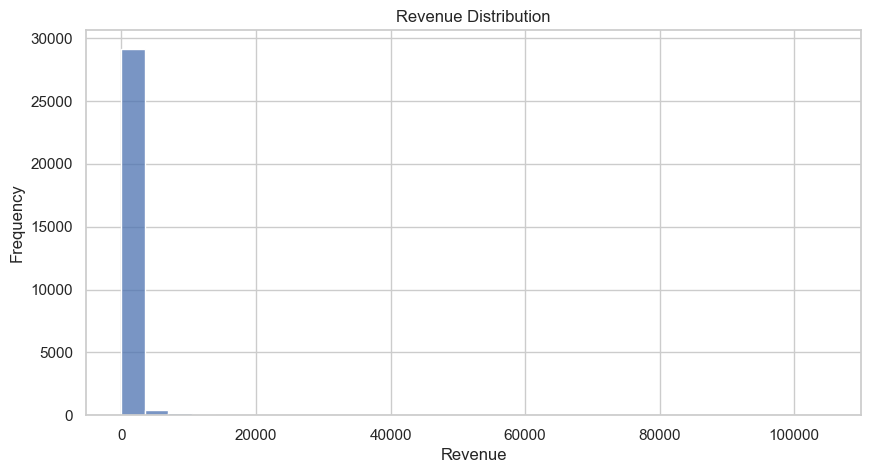

In [20]:
# ============================================================
# Revenue distribution
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x=target,
    bins=30
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

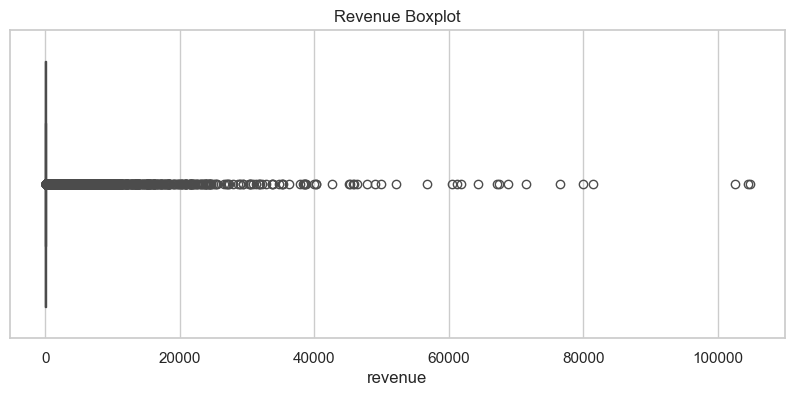

In [21]:
# ============================================================
# Revenue boxplot
# ============================================================

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df[target]
)

plt.title("Revenue Boxplot")

plt.show()

In [22]:
# ============================================================
# Target variable summary
# ============================================================

print("=" * 60)
print("TARGET VARIABLE SUMMARY")
print("=" * 60)

print(f"Target variable : {target}")
print(f"Prediction stage: Before campaign launch")
print(f"Minimum revenue : {df[target].min():,.2f}")
print(f"Maximum revenue : {df[target].max():,.2f}")
print(f"Mean revenue    : {df[target].mean():,.2f}")
print(f"Median revenue  : {df[target].median():,.2f}")

TARGET VARIABLE SUMMARY
Target variable : revenue
Prediction stage: Before campaign launch
Minimum revenue : 0.00
Maximum revenue : 104,733.41
Mean revenue    : 475.71
Median revenue  : 0.00


### Preliminary Conclusions

The descriptive analysis confirms that `revenue` is an appropriate target variable for this project.

The target exhibits a highly right-skewed distribution, with a median of **0.00** and a small number of campaigns generating very high revenue values. This indicates that most campaigns produce little or no revenue, while a limited number account for the highest returns.

The presence of these extreme values should be considered during the modeling phase, as they may influence model performance and error metrics.

From a business perspective, `revenue` remains the most relevant target because it represents the economic outcome that marketing teams aim to estimate before launching a campaign.

The next step is to identify which variables are genuinely available during campaign planning and to exclude any post-launch performance metrics that could introduce data leakage into the predictive model.

# 9. Análisis preliminar de Data Leakage

## Objetivo

El objetivo de esta sección es identificar qué variables podrían introducir **data leakage** dentro del modelo predictivo.

En este proyecto, el modelo debe estimar el `revenue` de una campaña **antes de su lanzamiento**. Por tanto, solo podrán utilizarse variables disponibles durante la fase de planificación.

Cualquier métrica generada después del lanzamiento de la campaña no debe utilizarse como variable predictora, aunque tenga una alta relación estadística con `revenue`.

Esto es especialmente importante porque un modelo podría obtener buenos resultados utilizando variables como `clicks` o `conversions`, pero esas variables no estarían disponibles en el momento real de la predicción.

In [23]:
# ============================================================
# Feature availability analysis
# ============================================================

planning_time_features = [
    "date",
    "year",
    "month",
    "month_name",
    "week",
    "day_of_week",
    "post_hour",
    "season",
    "is_holiday",
    "is_holiday (text)",
    "is_weekend",
    "is_weekend (text)",
    "country",
    "market_tier",
    "account",
    "account_type",
    "platform",
    "placement",
    "funnel_stage",
    "objective",
    "theme",
    "spend"
]

post_launch_metrics = [
    "impressions",
    "reach",
    "frequency",
    "clicks",
    "conversions",
    "video_views"
]

identifier_features = [
    "campaign_id",
    "campaign_name",
    "ad_group_id",
    "ad_group_name",
    "ad_id",
    "ad_name"
]

print("=" * 60)
print("FEATURE AVAILABILITY ANALYSIS")
print("=" * 60)

print(f"Planning-time features: {len(planning_time_features)}")
print(f"Post-launch metrics: {len(post_launch_metrics)}")
print(f"Identifier features: {len(identifier_features)}")

FEATURE AVAILABILITY ANALYSIS
Planning-time features: 22
Post-launch metrics: 6
Identifier features: 6


In [24]:
# ============================================================
# Leakage policy summary
# ============================================================

feature_policy = pd.DataFrame({
    "feature_group": [
        "Planning-time features",
        "Post-launch metrics",
        "Identifier features"
    ],
    "usage_in_main_model": [
        "Allowed",
        "Excluded",
        "Excluded"
    ],
    "reason": [
        "Known before campaign launch",
        "Generated after campaign launch",
        "High-cardinality identifiers with low business generalization"
    ]
})

display(feature_policy)

,feature_group,usage_in_main_model,reason
0,Planning-time features,Allowed,Known before campaign launch
1,Post-launch metrics,Excluded,Generated after campaign launch
2,Identifier features,Excluded,High-cardinality identifiers with low business...


In [25]:
# ============================================================
# Correlation of post-launch metrics with revenue
# ============================================================

leakage_correlation = correlation_with_target[
    correlation_with_target.index.isin(post_launch_metrics)
].sort_values(ascending=False)

print("=" * 60)
print("POST-LAUNCH METRICS CORRELATION WITH REVENUE")
print("=" * 60)

display(leakage_correlation)

POST-LAUNCH METRICS CORRELATION WITH REVENUE


conversions    0.76
clicks         0.48
impressions    0.10
frequency      0.08
reach          0.07
video_views   -0.02
Name: revenue, dtype: float64

In [26]:
# ============================================================
# Final feature groups validation
# ============================================================

all_defined_features = (
    planning_time_features
    + post_launch_metrics
    + identifier_features
    + [target]
)

undefined_features = [
    col for col in df.columns
    if col not in all_defined_features
]

print("=" * 60)
print("FEATURE GROUP VALIDATION")
print("=" * 60)

print(f"Undefined features: {undefined_features}")

FEATURE GROUP VALIDATION
Undefined features: []


## Interpretación

Las métricas analizadas presentan distintos niveles de correlación con `revenue`.

| Variable | Correlación | Uso en el modelo principal |
|----------|------------:|----------------------------|
| conversions | 0.76 | ❌ Excluir (post-launch) |
| clicks | 0.48 | ❌ Excluir (post-launch) |
| impressions | 0.10 | ❌ Excluir (post-launch) |
| frequency | 0.08 | ❌ Excluir (post-launch) |
| reach | 0.07 | ❌ Excluir (post-launch) |
| video_views | -0.02 | ❌ Excluir (post-launch) |

Aunque algunas variables presentan una fuerte relación con el `revenue`, todas ellas se generan únicamente después del lanzamiento de la campaña.

Por tanto, no estarán disponibles cuando el modelo deba realizar una predicción antes de la ejecución de la campaña.

Utilizarlas produciría un caso de **data leakage**, generando métricas de entrenamiento artificialmente optimistas pero imposibles de reproducir en un escenario real.

En consecuencia, estas variables se excluirán del modelo principal y se conservarán únicamente para análisis descriptivos o comparaciones posteriores.

## Conclusiones preliminares

El análisis de correlación permite identificar varias relaciones relevantes con la variable objetivo (`revenue`).

### Variables más relacionadas con Revenue

Las variables con mayor correlación observada son:

- conversions (0.76)
- clicks (0.48)
- spend (0.19)

Estas relaciones son coherentes desde una perspectiva de negocio y sugieren que el rendimiento de la campaña influye significativamente en los ingresos generados.

### Posibles riesgos de Data Leakage

No se detectan evidencias de leakage directo en esta fase.

Sin embargo, variables como:

- conversions
- clicks
- impressions
- reach
- video_views

representan información obtenida una vez que la campaña está en ejecución.

Su utilización futura dependerá del momento en que se pretenda realizar la predicción.

### Variables altamente correlacionadas

Se identifican algunos casos de alta correlación entre variables predictoras:

- month ↔ week
- impressions ↔ reach

Estas relaciones deberán revisarse durante la fase de selección de variables para evitar redundancias innecesarias.

### Conclusión general

El dataset no presenta evidencias claras de fuga de información en esta etapa del análisis.

No obstante, será necesario definir formalmente el alcance funcional del modelo antes de decidir qué variables podrán utilizarse durante el entrenamiento.

### Nota metodológica

La alta correlación observada entre `conversions` y `revenue` confirma que el dataset contiene variables de resultado muy relacionadas con el objetivo.

Sin embargo, el propósito del proyecto no es explicar el comportamiento de campañas ya ejecutadas, sino estimar su rendimiento antes del lanzamiento.

Por esta razón, la selección de variables estará guiada por su disponibilidad temporal y no únicamente por su capacidad predictiva aparente.

# 10. Conclusiones del Dataset Assessment

## Resumen ejecutivo

Durante esta fase se realizó una auditoría inicial del dataset con el objetivo de evaluar su calidad, estructura y adecuación para desarrollar un modelo de Machine Learning capaz de **predecir los ingresos esperados de una campaña antes de su lanzamiento**.

Además de validar la calidad del conjunto de datos, esta auditoría permitió identificar qué variables estarán realmente disponibles en el momento de realizar la predicción y detectar aquellas que podrían introducir **data leakage** si fueran utilizadas durante el entrenamiento.

---

## Hallazgos principales

### Calidad de los datos

El dataset presenta una **alta calidad estructural**:

- No se detectaron valores nulos.
- No existen registros duplicados.
- No se identificaron variables constantes.
- Todas las columnas contienen información válida para el análisis inicial.

Estos resultados permiten iniciar el análisis exploratorio sin necesidad de realizar procesos intensivos de limpieza.

---

### Estructura general

El conjunto de datos contiene:

- **30.000 observaciones**
- **35 variables**

Las variables describen distintos aspectos de las campañas de marketing digital, incluyendo información:

- Temporal
- Geográfica
- Configuración de campaña
- Plataforma publicitaria
- Rendimiento posterior
- Resultados económicos

Esta diversidad permitirá analizar qué información resulta realmente útil para estimar el rendimiento económico de una campaña antes de su ejecución.

---

### Variable objetivo

La variable objetivo del proyecto será **`revenue`**.

Su distribución presenta características típicas de muchos problemas reales de negocio:

- Distribución fuertemente asimétrica.
- Gran concentración de campañas con ingresos bajos o nulos.
- Presencia de valores extremos.
- Media considerablemente superior a la mediana.

Aunque estas características supondrán un reto durante el modelado, representan adecuadamente el comportamiento esperado en campañas de marketing digital.

---

### Variables disponibles antes del lanzamiento

La auditoría permitió diferenciar dos grandes grupos de variables.

Las **variables disponibles antes del lanzamiento** incluyen información como:

- Fecha
- País
- Plataforma
- Tipo de cuenta
- Objetivo de campaña
- Funnel stage
- Placement
- Theme
- Market tier

Estas variables constituirán la base del modelo predictivo final, ya que son conocidas durante la fase de planificación de una campaña.

---

### Variables generadas tras el lanzamiento

También se identificaron variables que únicamente existen una vez que la campaña ha comenzado o finalizado:

- spend
- impressions
- reach
- frequency
- clicks
- conversions
- video_views

Aunque algunas presentan una elevada correlación con el revenue, no estarán disponibles cuando el modelo deba realizar una predicción antes del lanzamiento.

---

### Riesgo de Data Leakage

La auditoría confirmó la existencia de variables cuyo uso introduciría **data leakage**.

Entre ellas destacan:

- conversions
- clicks
- impressions
- reach
- frequency
- video_views
- spend

Estas variables contienen información generada durante o después de la ejecución de la campaña.

Su utilización permitiría al modelo aprender información del futuro, obteniendo métricas de entrenamiento artificialmente optimistas e imposibles de reproducir en un entorno real.

Por este motivo, estas variables **no formarán parte del modelo principal**, aunque podrán emplearse para análisis descriptivos o comparaciones posteriores.

---

### Variables potencialmente redundantes

También se detectaron relaciones elevadas entre algunos predictores, especialmente:

- month ↔ week
- impressions ↔ reach

Estas relaciones serán evaluadas durante la fase de selección de variables para evitar posibles problemas de multicolinealidad.

---

## Limitaciones identificadas

Aunque el dataset presenta una elevada calidad estructural, se identifican varios aspectos que deberán abordarse en fases posteriores:

- Distribución altamente asimétrica del revenue.
- Presencia de valores extremos.
- Necesidad de codificar correctamente las variables categóricas.
- Exclusión de variables generadas tras el lanzamiento.
- Posible multicolinealidad entre algunos predictores.

Ninguna de estas limitaciones compromete la viabilidad del proyecto, pero deberán considerarse durante el desarrollo del pipeline de Machine Learning.

---

## Decisiones adoptadas

Tras completar la auditoría inicial se establecen las siguientes decisiones:

- Mantener **`revenue`** como variable objetivo.
- Construir el modelo utilizando exclusivamente variables disponibles **antes del lanzamiento de la campaña**.
- Excluir del entrenamiento todas las métricas generadas durante la ejecución de la campaña.
- Analizar la importancia de las variables mediante técnicas de Feature Engineering.
- Documentar todas las decisiones de preprocesamiento y selección de variables para garantizar la trazabilidad del proyecto.

---

## Impacto en el proyecto

Esta auditoría reduce significativamente el riesgo de construir un modelo poco realista.

La identificación temprana de variables con riesgo de data leakage permitirá desarrollar un modelo aplicable en escenarios reales de planificación de campañas y no únicamente como un ejercicio académico.

Además, establece una base sólida para las siguientes fases de Exploratory Data Analysis (EDA), ingeniería de variables y modelado.

---

## Valor para el negocio

El objetivo del proyecto deja de ser explicar el rendimiento de campañas ya ejecutadas y pasa a resolver un problema de negocio mucho más útil:

**estimar los ingresos potenciales de una campaña antes de invertir presupuesto en ella.**

Una herramienta con estas características podría ayudar a equipos de Marketing y Growth a:

- Priorizar campañas.
- Comparar escenarios de inversión.
- Optimizar presupuestos.
- Reducir el riesgo económico.
- Apoyar la toma de decisiones basada en datos.

---

## Conclusión técnica

La auditoría confirma que el dataset es adecuado para desarrollar un modelo de regresión orientado a la planificación de campañas.

No obstante, también demuestra que una parte importante de las variables disponibles corresponden a métricas posteriores al lanzamiento y, por tanto, deberán excluirse del modelo principal para evitar data leakage.

La siguiente fase consistirá en realizar un Exploratory Data Analysis (EDA) centrado exclusivamente en las variables disponibles antes del lanzamiento y evaluar su capacidad predictiva sobre el revenue.

---

## Próximas etapas

Con la auditoría completada, el proyecto continuará con las siguientes actividades:

1. Realizar el Exploratory Data Analysis (EDA).
2. Analizar únicamente las variables disponibles antes del lanzamiento.
3. Diseñar el pipeline de preprocesamiento.
4. Construir nuevas variables mediante Feature Engineering.
5. Seleccionar los predictores más relevantes.
6. Entrenar y comparar distintos modelos de regresión.
7. Evaluar su rendimiento mediante validación cruzada.

---

## Cierre de la fase

La fase **Dataset Assessment** concluye confirmando que el dataset posee la calidad necesaria para continuar con el proyecto y que la redefinición del objetivo de negocio ha quedado correctamente incorporada al diseño del modelo.

A partir de este momento, todas las decisiones de análisis y modelado estarán orientadas a construir un sistema capaz de **predecir el revenue esperado de una campaña utilizando únicamente la información disponible antes de su lanzamiento**, garantizando así un modelo útil, reproducible y aplicable en un contexto real de marketing y growth.